In [9]:
# 0. IMPORTS & CONFIG

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

# Visual style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [14]:
# 1. LOAD DATA

df = pd.read_csv("C:/Users/Admin/Documents/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Shape :", df.shape)
print(f"Attrition rate: {df['Attrition'].value_counts(normalize=True)['Yes']*100:.1f}%")

df.head(5)


Shape : (1470, 35)
Attrition rate: 16.1%


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [15]:
# 2. CLEANING

# Colonnes sans valeur analytique
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, inplace=True)

# Target binaire
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})


In [16]:
# 3. FEATURE ENGINEERING

# Découpe le salaire en 4 groupes
df['Income_Level'] = pd.qcut(
    df['MonthlyIncome'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

df['Distance_Risk'] = (df['DistanceFromHome'] > 15).astype(int)
df['Overtime_Risk'] = ((df['OverTime'] == 'Yes') & (df['WorkLifeBalance'] <= 2)).astype(int)
df['Career_Stagnation'] = (df['YearsSinceLastPromotion'] > 3).astype(int)


In [17]:
# 4. ENCODING

# Ordinal encoding
income_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
df['Income_Level'] = df['Income_Level'].map(income_map)

# One-hot encoding 
categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Final shape after encoding:", df.shape)


Final shape after encoding: (1470, 49)


In [18]:
df.head(5)

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [19]:
# 5. TRAIN / TEST SPLIT

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print(f"Train attrition rate: {y_train.mean()*100:.1f}%")
print(f"Test attrition rate : {y_test.mean()*100:.1f}%")


Train attrition rate: 16.2%
Test attrition rate : 16.0%


In [20]:
# 6. MODELING

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]


In [21]:
# 7. EVALUATION

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Reste', 'Part']))


ROC-AUC: 0.7598595798365422

Classification Report:

              precision    recall  f1-score   support

       Reste       0.86      0.96      0.91       309
        Part       0.48      0.19      0.27        59

    accuracy                           0.84       368
   macro avg       0.67      0.57      0.59       368
weighted avg       0.80      0.84      0.81       368



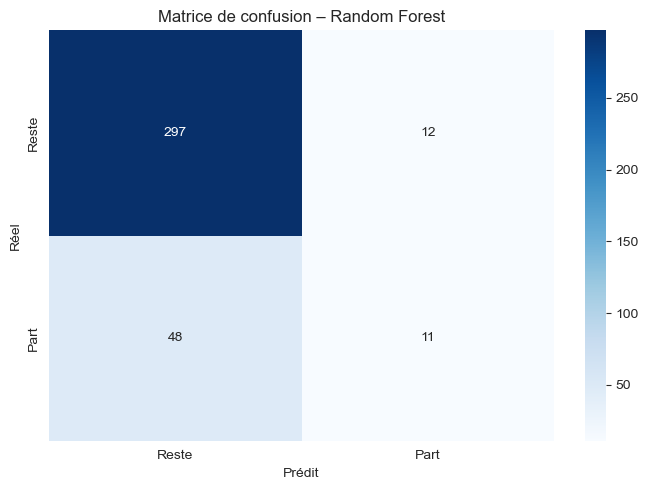

In [26]:
# Matrice de confusion

plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Reste', 'Part'],
    yticklabels=['Reste', 'Part']
)
plt.title("Matrice de confusion – Random Forest")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()
plt.show()


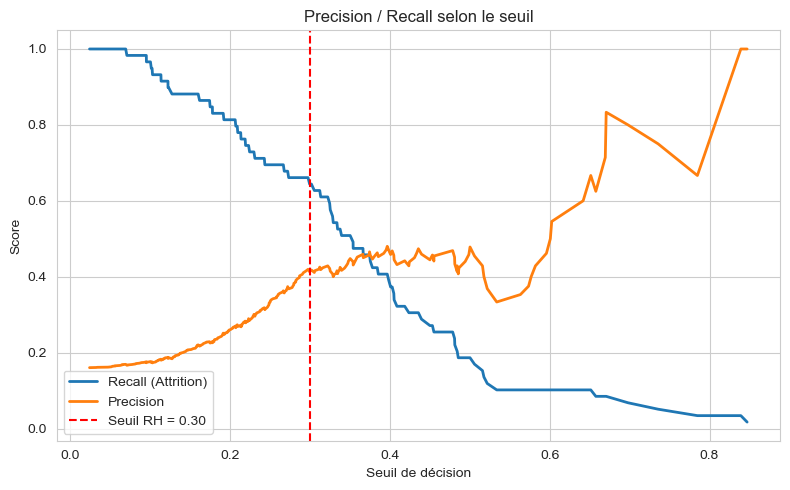

In [23]:
# 8. THRESHOLD ADJUSTMENT

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, recall[:-1], label='Recall (Attrition)', linewidth=2)
plt.plot(thresholds, precision[:-1], label='Precision', linewidth=2)
plt.axvline(x=0.3, color='red', linestyle='--', label='Seuil RH = 0.30')
plt.xlabel('Seuil de décision')
plt.ylabel('Score')
plt.title('Precision / Recall selon le seuil')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
# Seuil métier choisi
THRESHOLD = 0.30

y_pred_threshold = (y_proba >= THRESHOLD).astype(int)

print("=== ÉVALUATION AVEC SEUIL 0.30 ===\n")
print(classification_report(
    y_test,
    y_pred_threshold,
    target_names=['Reste', 'Part']
))


=== ÉVALUATION AVEC SEUIL 0.30 ===

              precision    recall  f1-score   support

       Reste       0.92      0.83      0.87       309
        Part       0.42      0.64      0.51        59

    accuracy                           0.80       368
   macro avg       0.67      0.74      0.69       368
weighted avg       0.84      0.80      0.81       368



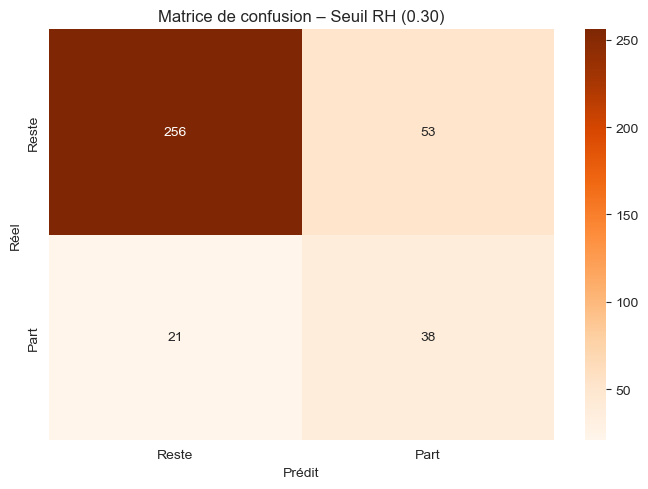

In [25]:
# Nouvelle matrice de confusion

plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_threshold),
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Reste', 'Part'],
    yticklabels=['Reste', 'Part']
)
plt.title('Matrice de confusion – Seuil RH (0.30)')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()


In [27]:
# 9. EXPORT EMPLOYÉS À RISQUE

# Probabilité d'attrition sur toute la base
df['Attrition_Probability'] = rf.predict_proba(X)[:, 1]

# Flag RH
df['High_Risk_Flag'] = (df['Attrition_Probability'] >= THRESHOLD).astype(int)


In [28]:
employees_at_risk = df[df['High_Risk_Flag'] == 1].copy()

print(f"Nombre d'employés à risque détectés : {employees_at_risk.shape[0]}")
print(f"Taux estimé de départ dans ce groupe : "
      f"{employees_at_risk['Attrition_Probability'].mean():.2f}")


Nombre d'employés à risque détectés : 330
Taux estimé de départ dans ce groupe : 0.57


In [29]:
# Export CSV pour les RH

cols_for_hr = [
    'Attrition_Probability',
    'MonthlyIncome',
    'DistanceFromHome',
    'WorkLifeBalance',
    'JobSatisfaction',
    'OverTime_Yes',
    'YearsSinceLastPromotion'
]

employees_at_risk[cols_for_hr].sort_values(
    'Attrition_Probability',
    ascending=False
).to_csv(
    'employees_high_risk_attrition.csv',
    index=False
)

print("✅ Fichier 'employees_high_risk_attrition.csv' exporté pour action RH")


✅ Fichier 'employees_high_risk_attrition.csv' exporté pour action RH


In [30]:
# 10. SMOTE + MODEL

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.5,  # 1 départ pour 2 restes (réaliste)
    random_state=42
)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :", y_train.value_counts().to_dict())
print("Après SMOTE  :", y_train_sm.value_counts().to_dict())


Avant SMOTE : {0: 924, 1: 178}
Après SMOTE  : {0: 924, 1: 462}


In [31]:
#Ré-entraînement du modèle

rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_sm, y_train_sm)

y_proba_sm = rf_smote.predict_proba(X_test)[:, 1]
y_pred_sm = (y_proba_sm >= THRESHOLD).astype(int)

print("=== RANDOM FOREST + SMOTE + SEUIL 0.30 ===\n")
print(classification_report(
    y_test,
    y_pred_sm,
    target_names=['Reste', 'Part']
))


=== RANDOM FOREST + SMOTE + SEUIL 0.30 ===

              precision    recall  f1-score   support

       Reste       0.92      0.79      0.85       309
        Part       0.38      0.66      0.48        59

    accuracy                           0.77       368
   macro avg       0.65      0.73      0.67       368
weighted avg       0.84      0.77      0.79       368

